This is the code for the final project in ECSE 343: Numerical Methods for Engs. Our team, group 20, is made up of
- Serge Al Laham
- Emily Wang
- Jeremias Zimmerman
- Steven Thao

# Part 1: Data generation

# 1.1 Dataset generation

Creating dataset...


  0%|          | 0/3000 [00:00<?, ?it/s]

Dataset created successfully


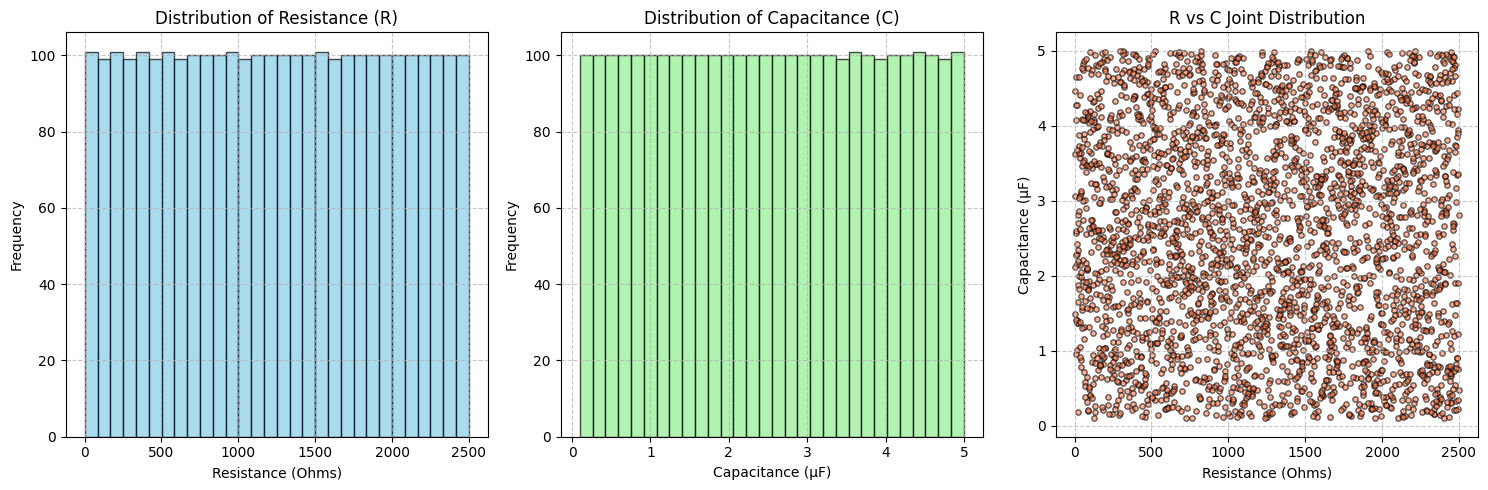

In [31]:
import importlib
import helper_functions
importlib.reload(helper_functions)
from helper_functions import create_dataset, plot_rc_distribution

# variables
num_samples = 3000
amplitude = 5.0
f = 60.0
delta_t = 0.0001
T = 0.05
noise = 0.1

x, y = create_dataset(num_samples, amplitude, f, delta_t, T, noise)
plot_rc_distribution(y)

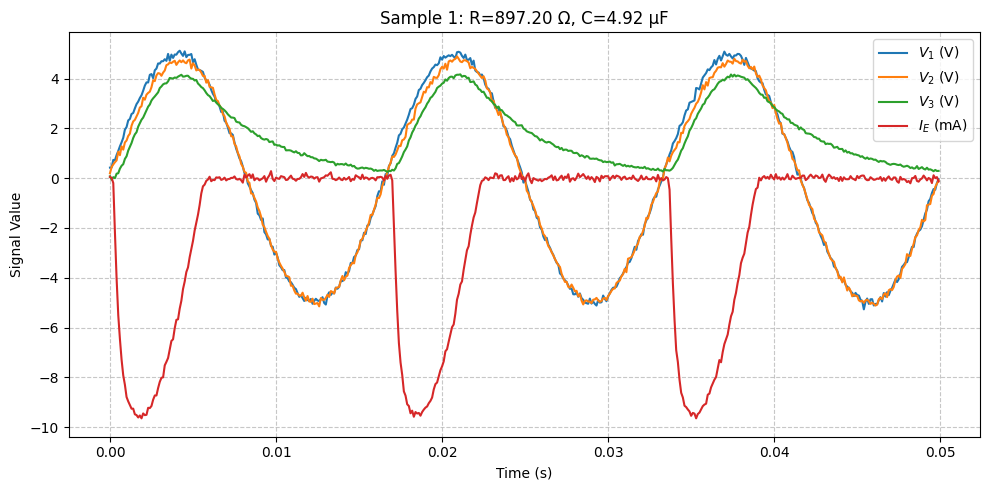

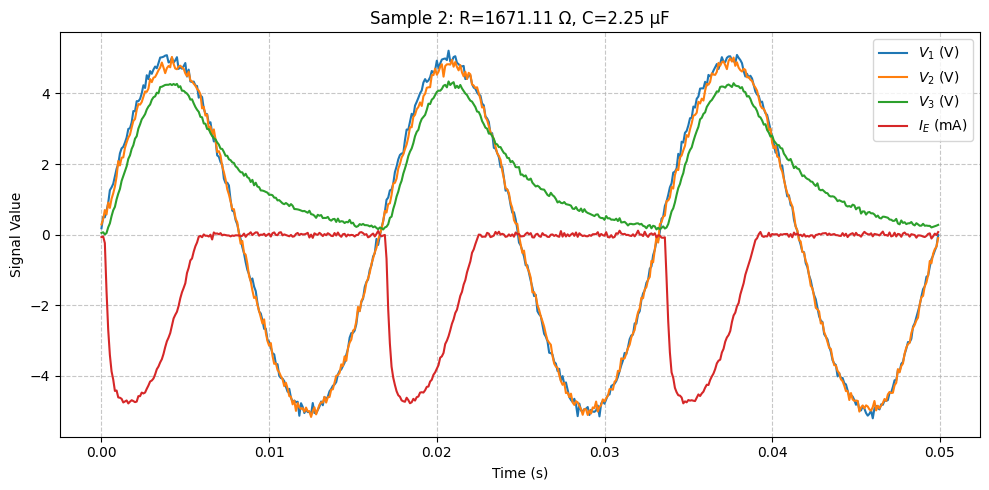

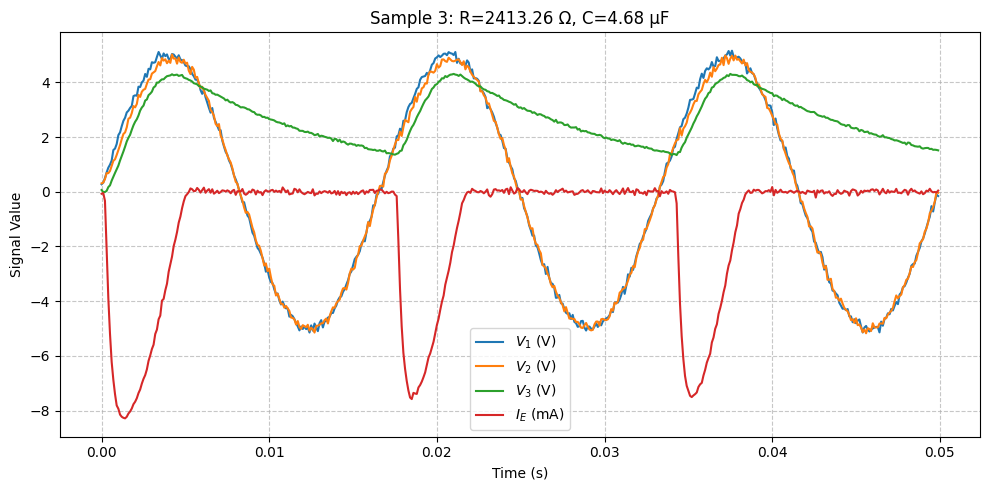

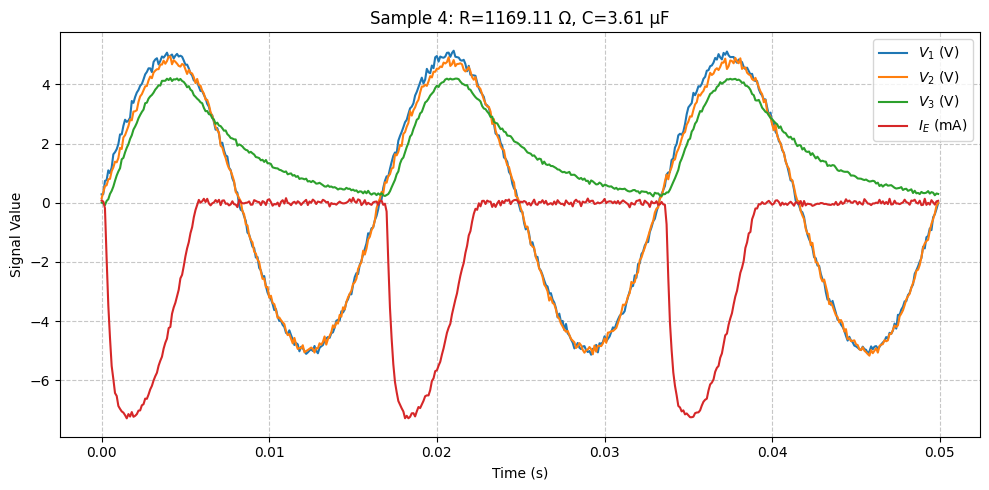

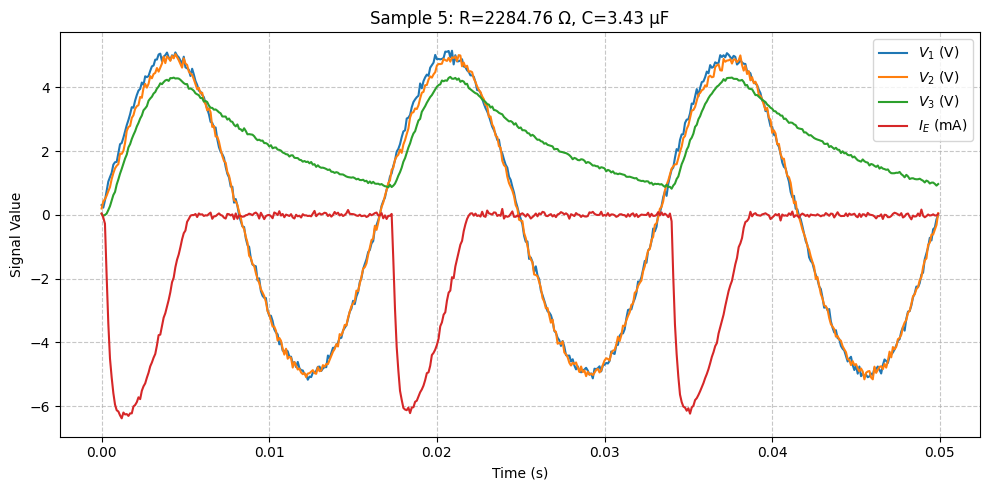

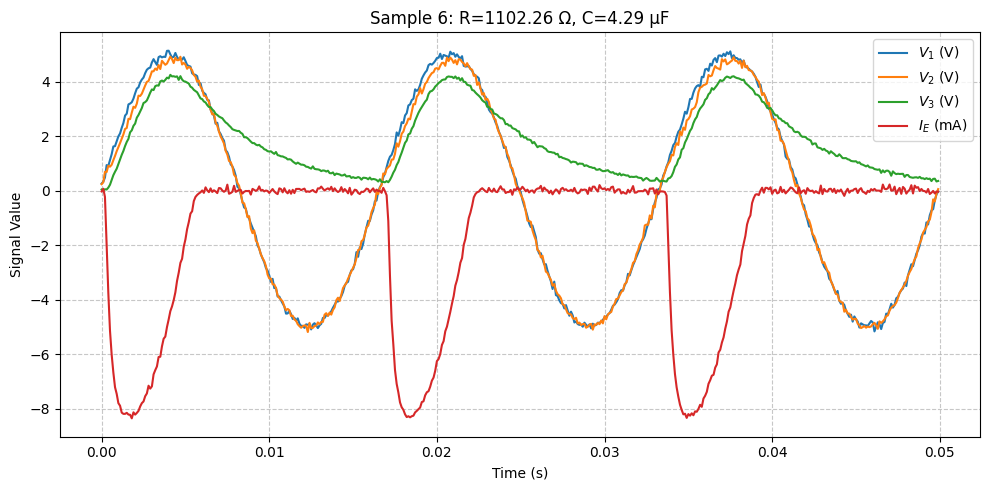

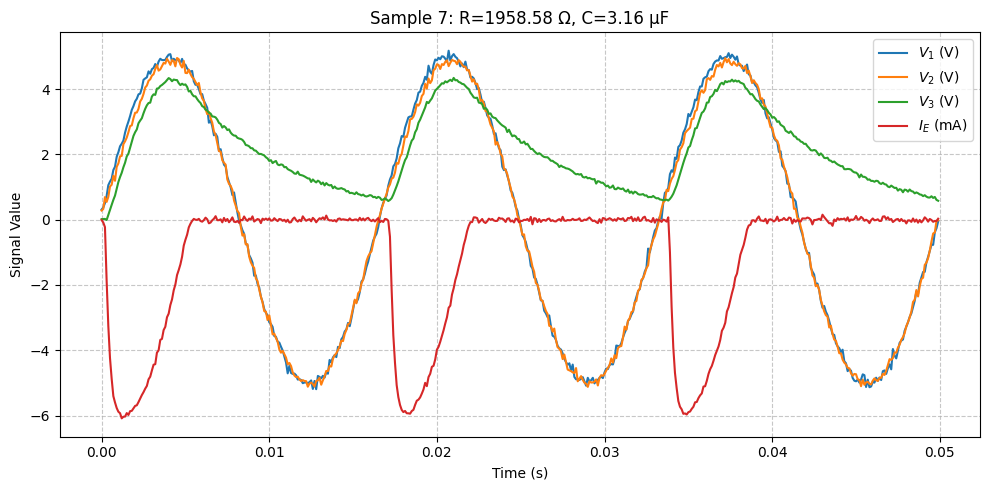

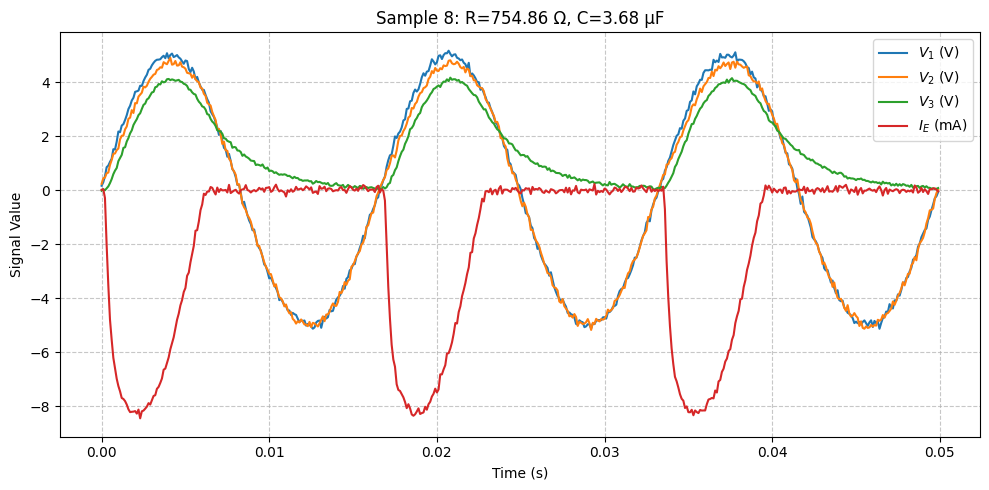

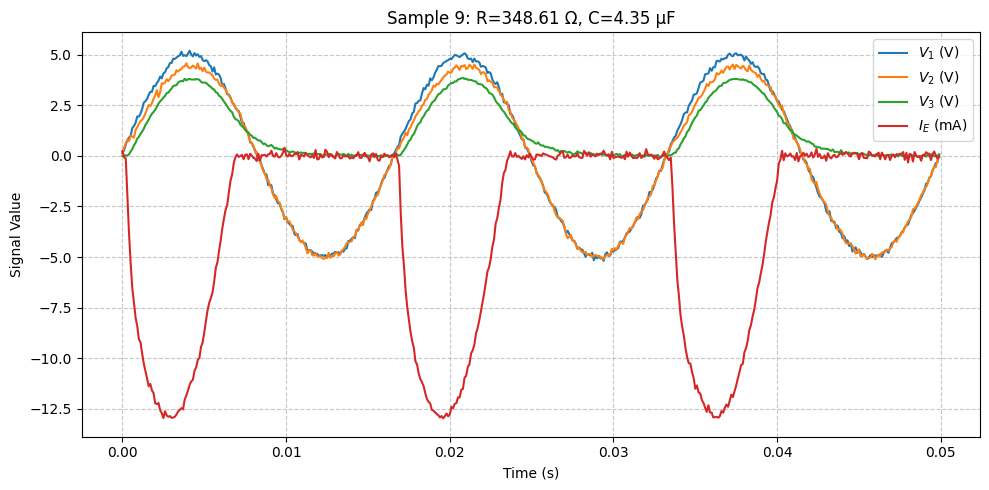

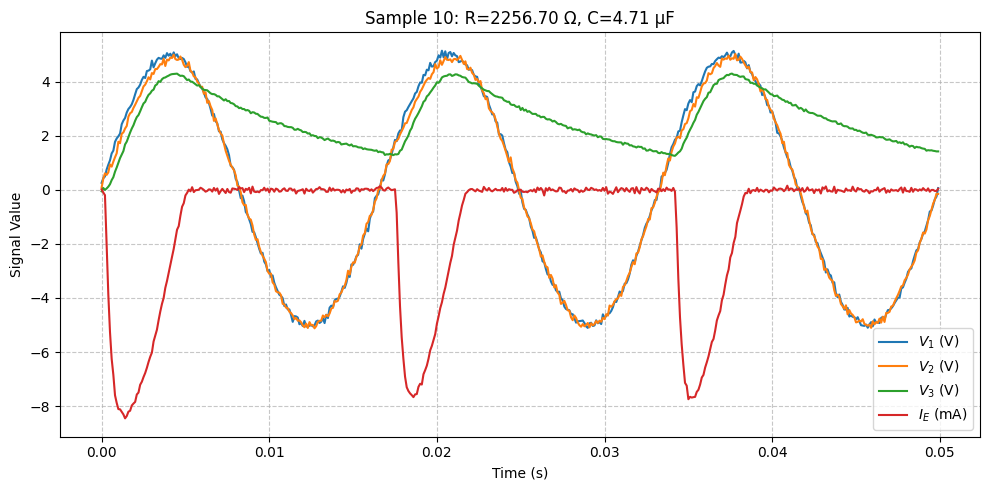

In [ ]:
# Plotting sample signals
import numpy as np
import matplotlib.pyplot as plt

random_samples_idx = np.random.randint(0, num_samples, 10)
random_samples = x[random_samples_idx]
random_samples_y = y[random_samples_idx]

tpoints = np.arange(x.shape[1]) * delta_t
signal_names = [r"$V_1$ (V)", r"$V_2$ (V)", r"$V_3$ (V)", r"$I_E$ (mA)"]

for i, (sample, label) in enumerate(zip(random_samples, random_samples_y)):
    plt.figure(figsize=(10, 5))
    for j in range(4):
        plt.plot(tpoints, sample[:, j], label=signal_names[j])
    plt.xlabel("Time (s)")
    plt.ylabel("Signal Value")
    plt.title(f"Sample {i+1}: R={np.exp(label[0]):.2f} Ω, C={np.exp(label[1])*1e6:.2f} μF")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 1.2 Data Pre-processing (FFT)

In [32]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

def calibrate(reference_filename: str) -> dict:
    """
    Run once on a representative simulation to fix the frequency bin indices.
    Returns a dict of locked indices used by get_feature_vector for every simulation.
    """
    data = pd.read_csv(reference_filename, header=None)
    signals = np.array([data[col] for col in data.columns]) # (4, 500)
    features = np.fft.rfft(signals, axis=1) # (4, 251)

    indices = {}

    print("Calibrating indices...")
    for idx, row in tqdm(enumerate(features)):
        if idx < 2:
            top_idx = np.argmax(np.abs(row[1:])) + 1
            indices[idx] = top_idx

        else:
            ac_mag  = np.abs(row[1:])
            top5_idx = np.argsort(ac_mag)[::-1][:5]
            indices[idx] = top5_idx

    return indices

"""
    Get the feature vector for one instance from the dataset.

    Input:
        x: numpy array of shape (4, 500)
        indices: dictionary of locked indices
    Output:
        feature_vector: numpy array of shape (26,)
"""
def get_feature_vector(x, indices: dict) -> np.ndarray:
    """
    Build the feature vector using the fixed bin indices from calibrate().
    Layout: [mag_11, ph_11, mag_21, ph_21,
             DC_3, mag_31, ph_31, ..., ph_35,
             DC_4, mag_41, ph_41, ..., ph_45] -> shape (26,)
    """
    signals = x.T
    features = np.fft.rfft(signals, axis=1) # (4, 251)

    feature_vector = []

    for idx, row in enumerate(features):
        if idx < 2:
            i = indices[idx]
            feature_vector += [np.abs(row[i]), np.angle(row[i])]

        else:
            dc = np.abs(row[0])
            ac_mag = np.abs(row[1:])
            ac_phs = np.angle(row[1:])

            feature_vector.append(dc)
            for i in indices[idx]:
                feature_vector += [ac_mag[i], ac_phs[i]]

    return np.array(feature_vector)

indices = calibrate('../data/measurements.csv')

# building feature matrix
feature_matrix = []
print("Building feature matrix...")
for sample in tqdm(x):
    feature_vector = get_feature_vector(sample, indices)
    feature_matrix.append(feature_vector)

feature_matrix = np.array(feature_matrix)


Calibrating indices...


0it [00:00, ?it/s]

Building feature matrix...


  0%|          | 0/3000 [00:00<?, ?it/s]

# Part 2: Newton-Raphson method

# Part 3: ML solution

In [14]:
# imports
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
"""
    Base class for multivariate polynomial regression
"""
class PolyReg(nn.Module):
    def __init__(self, degree: int, lr: float = 0.001):
        super().__init__()
        self.degree = degree
        self.hidden = nn.Linear(26 * degree, 2)
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

    def forward(self, x):
        poly_features = [x ** i for i in range(1, self.degree + 1)]
        poly_features = torch.cat(poly_features, dim=0)  # 1D samples → dim=0
        return self.hidden(poly_features)

    """
    Trains the model.

    Input:
        x_train: N x 26 matrix of all training inputs
        y_train: N x 2 matrix of all training labels
        epochs: Training epochs
    Output:
        None
    """
    def train(self, x_train, y_train, epochs=100, x_val=None, y_val=None):
        train_losses = []
        val_losses = [] if x_val is not None and y_val is not None else None
        pbar = tqdm(range(epochs), desc="Training", unit="epoch")
        for epoch in pbar:
            epoch_loss = 0.0
            for x, y in zip(x_train, y_train):
                self.optimizer.zero_grad()
                outputs = self.forward(x)
                loss = self.loss_fn(outputs.squeeze(), y)
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item()
            train_loss = epoch_loss / len(x_train)
            train_losses.append(train_loss)
            postfix = {"train_loss": f"{train_loss:.4f}"}
            if val_losses is not None:
                val_loss = self.val_test(x_val, y_val)
                val_losses.append(val_loss)
                postfix["val_loss"] = f"{val_loss:.4f}"
            pbar.set_postfix(postfix)
        return train_losses, val_losses

    """
        Obtains the test score for the model.

        Input:
            x_test: N x 26 matrix of all test inputs
            y_test: N x 2 matrix of all test labels
        Output:
            resul: validation accuracy for the current test set
    """
    def val_test(self, x_test: torch.Tensor, y_test: torch.Tensor) -> float:
        total_loss = 0.0

        with torch.no_grad():
            for x, y in zip(x_test, y_test):
                pred = self.forward(x)
                loss = self.loss_fn(pred, y)
                total_loss += loss.item()

        return total_loss / len(x_test)

In [24]:
"""
    Class for simple feedforward neural network.
"""
class NeuralNet(nn.Module):
    """
    For now, the activation function is ReLU. Can adapt to other functions in the future.

    Input:
        units: list of number of units in each layer, including input and output layers.
    Output:
        NeuralNet object.
    """
    def __init__(self, units: list[int], lr: float = 0.001) -> None:
        super().__init__()
        self.hidden = nn.ModuleList([nn.Linear(units[i], units[i + 1]) for i in range(len(units) - 1)])
        self.activation = nn.ReLU()
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.hidden[:-1]:
            x = self.activation(layer(x))
        return self.hidden[-1](x)

    """
    Trains the model.

    Input:
        x_train: N x 26 matrix of all training inputs
        y_train: N x 2 matrix of all training labels
        epochs: Training epochs
    Output:
        None
    """
    def train(self, x_train, y_train, epochs=100, x_val=None, y_val=None):
        train_losses = []
        val_losses = [] if x_val is not None and y_val is not None else None
        pbar = tqdm(range(epochs), desc="Training", unit="epoch")
        for epoch in pbar:
            epoch_loss = 0.0
            for x, y in zip(x_train, y_train):
                self.optimizer.zero_grad()
                outputs = self.forward(x)
                loss = self.loss_fn(outputs.squeeze(), y)
                loss.backward()
                self.optimizer.step()
                epoch_loss += loss.item()
            train_loss = epoch_loss / len(x_train)
            train_losses.append(train_loss)
            postfix = {"train_loss": f"{train_loss:.4f}"}
            if val_losses is not None:
                val_loss = self.val_test(x_val, y_val)
                val_losses.append(val_loss)
                postfix["val_loss"] = f"{val_loss:.4f}"
            pbar.set_postfix(postfix)
        return train_losses, val_losses


    """
        Obtains the test score for the model.

        Input:
            x_test: N x 26 matrix of all test inputs
            y_test: N x 2 matrix of all test labels
        Output:
            resul: validation accuracy for the current test set
    """
    def val_test(self, x_test: torch.Tensor, y_test: torch.Tensor) -> float:
        total_loss = 0.0

        with torch.no_grad():
            for x, y in zip(x_test, y_test):
                pred = self.forward(x)
                loss = self.loss_fn(pred, y)
                total_loss += loss.item()

        return total_loss / len(x_test)

In [16]:
def split_dataset(dataset: tuple[torch.Tensor, torch.Tensor], train_ratio: float = 0.7, val_ratio: float = 0.15) -> tuple[tuple[torch.Tensor, torch.Tensor], tuple[torch.Tensor, torch.Tensor], tuple[torch.Tensor, torch.Tensor]]:
    """
    Split dataset into training, validation, and test sets.

    Input:
        dataset: single tuple of (X, y) where X is all the input data and y is all the labels.
        train_ratio: decimal ratio of training data.
        val_ratio: decimal ratio of validation data.
    Output:
        tuple of (X_train, y_train), (X_val, y_val), (X_test, y_test) where X and y are torch tensors.
    """
    X, y = dataset
    n_samples = X.shape[0]
    # shuffle indices
    indices = np.random.permutation(n_samples)
    # calculate split indices
    train_end = int(train_ratio * n_samples)
    val_end = int((train_ratio + val_ratio) * n_samples)

    # do the split
    X_train, y_train = X[indices[:train_end]], y[indices[:train_end]]
    X_val, y_val = X[indices[train_end:val_end]], y[indices[train_end:val_end]]
    X_test, y_test = X[indices[val_end:]], y[indices[val_end:]]

    return (torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)), (torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32)), (torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

Training set: torch.Size([2100, 26]) torch.Size([2100, 2])
Validation set: torch.Size([450, 26]) torch.Size([450, 2])
Test set: torch.Size([450, 26]) torch.Size([450, 2])

Training Neural Network 5 times for confidence intervals...
Run 1


Training:   0%|          | 0/150 [00:00<?, ?epoch/s]

Run 2


Training:   0%|          | 0/150 [00:00<?, ?epoch/s]

Run 3


Training:   0%|          | 0/150 [00:00<?, ?epoch/s]

Run 4


Training:   0%|          | 0/150 [00:00<?, ?epoch/s]

Run 5


Training:   0%|          | 0/150 [00:00<?, ?epoch/s]

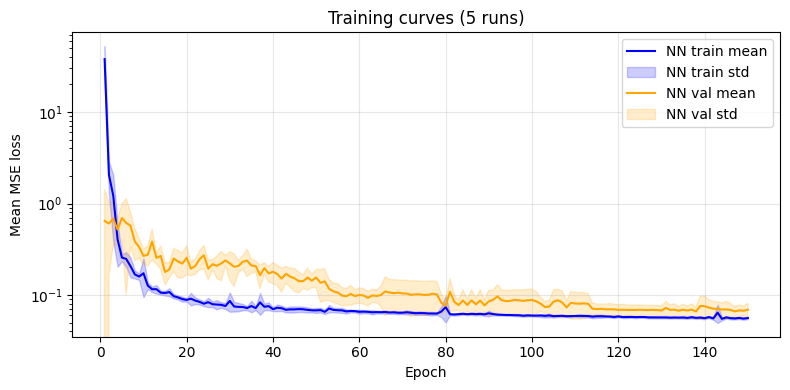

In [25]:
# TESTING: Assumed dataset:
# dataset = {(x^(i), y^(i))} for i in [1, N]
# In reality, dataset = (X, y), with X being an N x 26 matrix, and y being an N x 2 matrix.
# y^{(i)} = (R^{(i)}, C^{(i)})
# x^{(i)} = 26-length real-valued vector of features for the ith simulation.

# 1. Split dataset into training, validation, and test sets.
# example dataset with 100 samples, 26 features, and 2 labels
dataset = (feature_matrix, y)
D_train, D_val, D_test = split_dataset(dataset, train_ratio=0.7, val_ratio=0.15)
print("Training set:", D_train[0].shape, D_train[1].shape)
print("Validation set:", D_val[0].shape, D_val[1].shape)
print("Test set:", D_test[0].shape, D_test[1].shape)

# 2. Setup training parameters for multiple runs
import matplotlib.pyplot as plt

units = [26, 64, 64, 2] # 26 inputs, 3 hidden layers, 2 outputs
num_runs = 5
epochs = 150

all_nn_train = []
all_nn_val = []

print(f"\nTraining Neural Network {num_runs} times for confidence intervals...")

# 3. Train neural network multiple times
for run in range(1, num_runs + 1):
    print(f"Run {run}")
    network = NeuralNet(units, lr=0.001)
    nn_train, nn_val = network.train(
        D_train[0], D_train[1], epochs=epochs, x_val=D_val[0], y_val=D_val[1]
    )
    all_nn_train.append(nn_train)
    if nn_val is not None:
        all_nn_val.append(nn_val)

# Convert to numpy arrays to compute mean and std
all_nn_train = np.array(all_nn_train)
all_nn_val = np.array(all_nn_val) if len(all_nn_val) > 0 else None

train_mean = all_nn_train.mean(axis=0)
train_std = all_nn_train.std(axis=0)

if all_nn_val is not None:
    val_mean = all_nn_val.mean(axis=0)
    val_std = all_nn_val.std(axis=0)

# 4. Plotting with confidence intervals
fig, ax = plt.subplots(figsize=(8, 4))
epochs_nn = range(1, epochs + 1)

ax.plot(epochs_nn, train_mean, label="NN train mean", color='blue')
ax.fill_between(epochs_nn, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2, label="NN train std")

if all_nn_val is not None:
    ax.plot(epochs_nn, val_mean, label="NN val mean", color='orange')
    ax.fill_between(epochs_nn, val_mean - val_std, val_mean + val_std, color='orange', alpha=0.2, label="NN val std")

ax.set_xlabel("Epoch")
ax.set_ylabel("Mean MSE loss")
ax.set_yscale("log")
ax.set_title(f"Training curves ({num_runs} runs)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
import pandas as pd
data = pd.read_csv("../data/measurements.csv", header=None).to_numpy(dtype=np.float64)
feature_vec = get_feature_vector(data, indices) # (26, )
x = torch.tensor(feature_vec, dtype=torch.float32).unsqueeze(0)  # (1, 26)

with torch.no_grad():
    log_pred = network(x)
    # Network was trained on log(R) and log(C) targets, so invert with exp()
    pred = torch.exp(log_pred)

R_pred, C_pred = pred[0, 0].item(), pred[0, 1].item()
print(f"Predicted R: {R_pred:.2f} Ohms")
print(f"Predicted C: {C_pred * 1e6:.4f} µF")

Predicted R: 2339.06 Ohms
Predicted C: 0.4854 µF
